In [ ]:
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import adjusted_rand_score
np.random.seed(42)

### Load anndata object from previous part

### PCA - Clustering

In [ ]:
sc.tl.pca(adata)

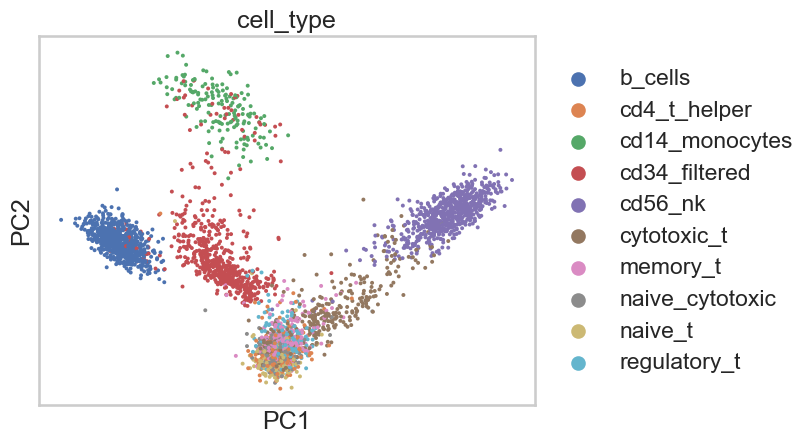

In [ ]:
sc.pl.pca(adata, color="cell_type")

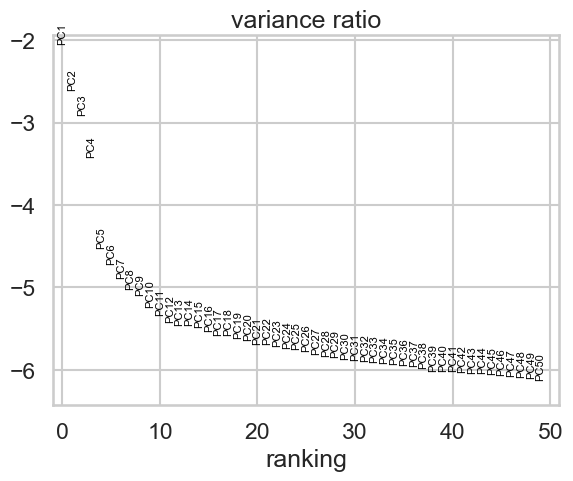

In [ ]:
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

In [ ]:
N_PCS = 20
sc.pp.neighbors(adata, n_pcs=N_PCS)
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution=0.5, key_added="leiden_r_0.5",flavor="igraph")

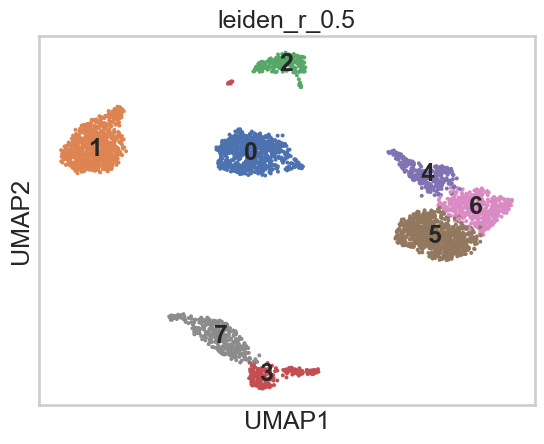

In [ ]:
sc.pl.umap(adata, color="leiden_r_0.5", legend_loc="on data")

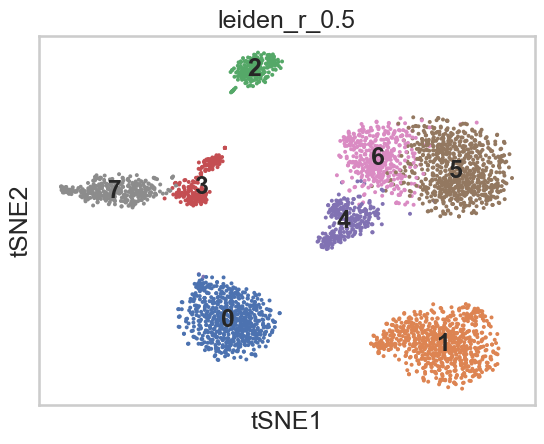

In [ ]:
sc.tl.tsne(adata)
sc.pl.tsne(adata, color="leiden_r_0.5", legend_loc="on data")

### Ok let's observe the effect of some parameters

In [ ]:
k_values = [5, 15, 30]
resolutions = [0.3, 0.5, 0.8, 1]

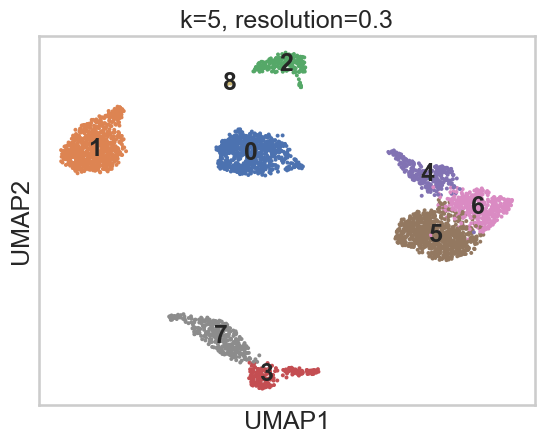

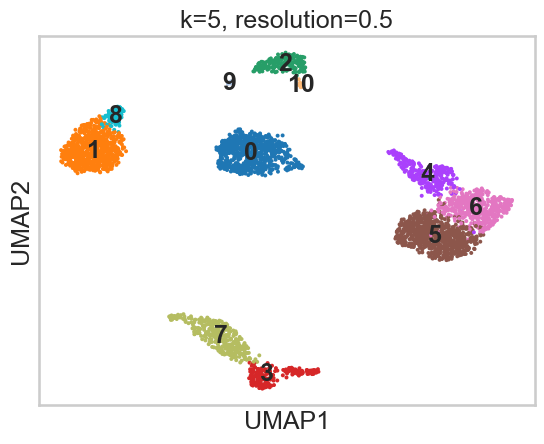

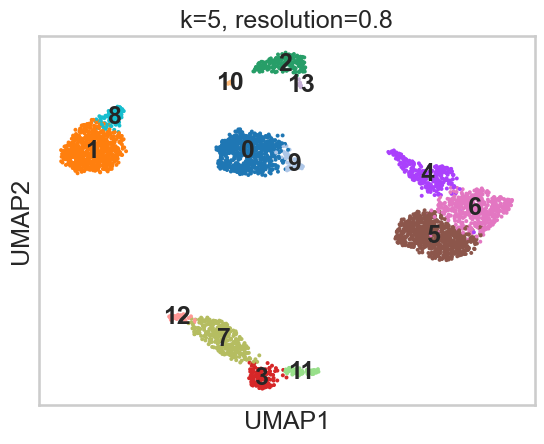

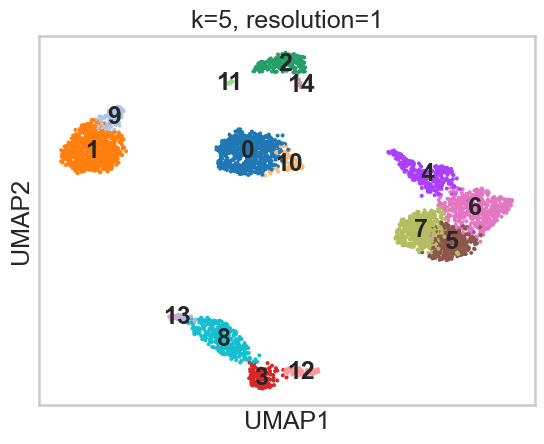

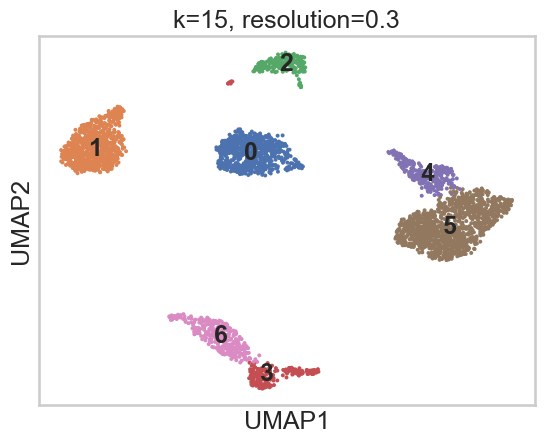

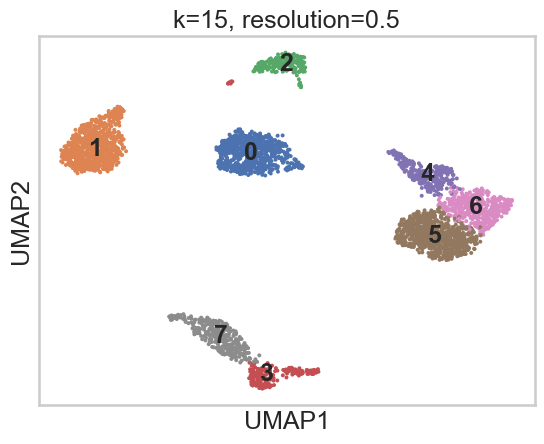

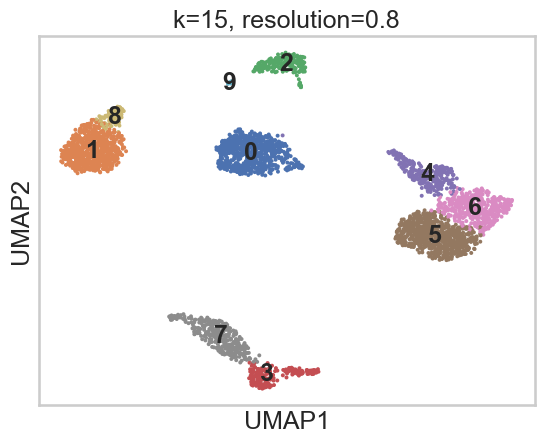

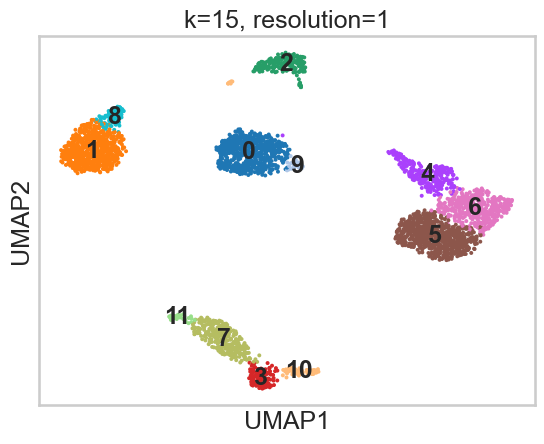

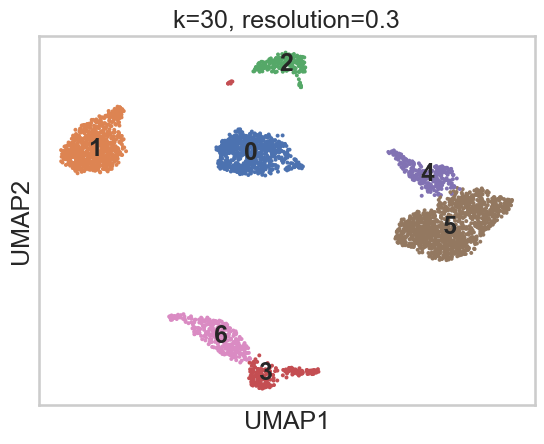

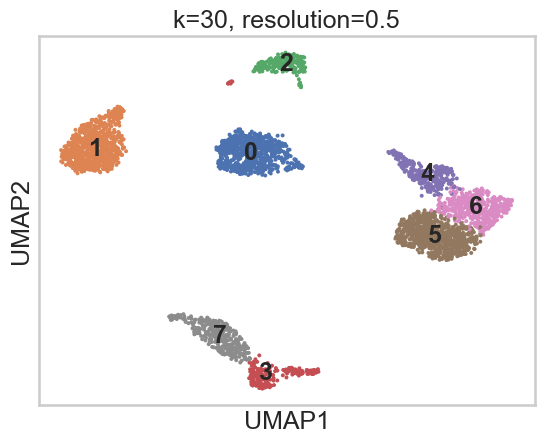

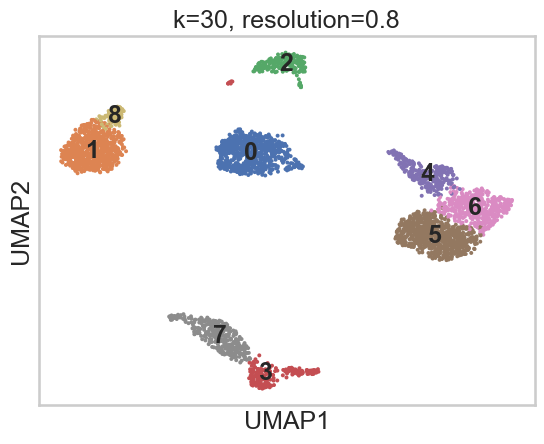

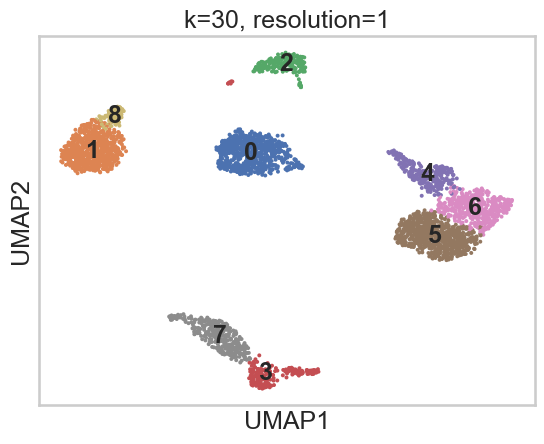

In [ ]:
for k in k_values:
    sc.pp.neighbors(
        adata,
        n_neighbors=k,
        n_pcs=N_PCS,
        key_added=f"neighbors_k{k}"
    )

    sc.tl.umap(
        adata,
        neighbors_key=f"neighbors_k{k}",
        key_added=f"X_umap_k{k}_"
    )

    for res in resolutions:
        cluster_key = f"leiden_k{k}_r_{res}"
        sc.tl.leiden(
            adata,
            resolution=res,
            neighbors_key=f"neighbors_k{k}",
            key_added=cluster_key,
            flavor="igraph"
        )

        sc.pl.umap(
        adata,
        color=cluster_key,
        neighbors_key=f"neighbors_k{k}",
        title=f"k={k}, resolution={res}",
        legend_loc="on data"
        )

In [ ]:
adata

AnnData object with n_obs × n_vars = 3695 × 14066
    obs: 'cell_type', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'leiden_r_0.5', 'leiden_k5_r_0.3', 'leiden_k5_r_0.5', 'leiden_k5_r_0.8', 'leiden_k5_r_1', 'leiden_k15_r_0.3', 'leiden_k15_r_0.5', 'leiden_k15_r_0.8', 'leiden_k15_r_1', 'leiden_k30_r_0.3', 'leiden_k30_r_0.5', 'leiden_k30_r_0.8', 'leiden_k30_r_1'
    var: 'n_cells', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'pca', 'cell_type_colors', 'neighbors', 'umap', 'leiden_r_0.5', 'leiden_r_0.5_colors', 'tsne',

In [ ]:
adata.obs

,cell_type,n_genes,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,...,leiden_k5_r_0.8,leiden_k5_r_1,leiden_k15_r_0.3,leiden_k15_r_0.5,leiden_k15_r_0.8,leiden_k15_r_1,leiden_k30_r_0.3,leiden_k30_r_0.5,leiden_k30_r_0.8,leiden_k30_r_1
AAACATACCCAATG_1_cd56_nk,cd56_nk,708,707,6.562444,1780.0,7.484930,40.674157,55.786517,70.112360,88.370787,...,0,0,0,0,0,0,0,0,0,0
AAACATACGAATAG_1_b_cells,b_cells,588,588,6.378426,1816.0,7.504942,46.696035,65.803965,78.634361,95.154185,...,1,1,1,1,1,1,1,1,1,1
AAACATACGTTCAG_1_cd14_monocytes,cd14_monocytes,348,348,5.855072,700.0,6.552508,45.142857,61.857143,78.857143,100.000000,...,2,2,2,2,2,2,2,2,2,2
AAACATTGCTGATG_1_b_cells,b_cells,439,439,6.086775,1078.0,6.983790,46.567718,63.172542,77.829314,100.000000,...,1,1,1,1,1,1,1,1,1,1
AAACATTGGTACGT_1_cd34_filtered,cd34_filtered,1123,1123,7.024649,3014.0,8.011355,37.591241,51.891175,64.167220,79.329794,...,3,3,3,3,3,3,3,3,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTCTACTGATAGA_1_cd56_nk,cd56_nk,661,660,6.493754,1566.0,7.356918,40.613027,55.938697,70.561941,89.782886,...,0,0,0,0,0,0,0,0,0,0
TTTGACTGCCTAAG_1_b_cells,b_cells,968,966,6.874198,3020.0,8.013343,41.920530,58.245033,70.827815,84.569536,...,8,9,1,1,8,8,1,1,8,8
TTTGACTGCTTGTT_1_b_cells,b_cells,618,618,6.428105,1862.0,7.529943,47.422127,65.950591,77.551020,93.662728,...,1,1,1,1,1,1,1,1,1,1
TTTGACTGTCAGAC_1_cd34_filtered,cd34_filtered,1432,1423,7.261225,4771.0,8.470521,40.222176,57.346468,68.224691,80.653951,...,7,8,6,7,7,7,6,7,7,7


### Use ARI -external clustering evaluation metric- to identify the best clustering parameters.

In [ ]:
reference_key = "cell_type" 
ari_results = []

for k in k_values:
    for res in resolutions:
        cluster_key = f"leiden_k{k}_r_{res}"

        ari = adjusted_rand_score( 
            adata.obs[reference_key],
            adata.obs[cluster_key]
        )

        ari_results.append({
            "k_neighbors": k,
            "resolution": res,
            "clusters": adata.obs[cluster_key].nunique(),
            "ARI": ari
        })

ari_df = pd.DataFrame(ari_results)
ari_df 

,k_neighbors,resolution,clusters,ARI
0,5,0.3,9,0.670552
1,5,0.5,11,0.648197
2,5,0.8,14,0.607328
3,5,1.0,15,0.642241
4,15,0.3,7,0.580506
5,15,0.5,8,0.679004
6,15,0.8,10,0.644523
7,15,1.0,12,0.612365
8,30,0.3,7,0.580144
9,30,0.5,8,0.681291


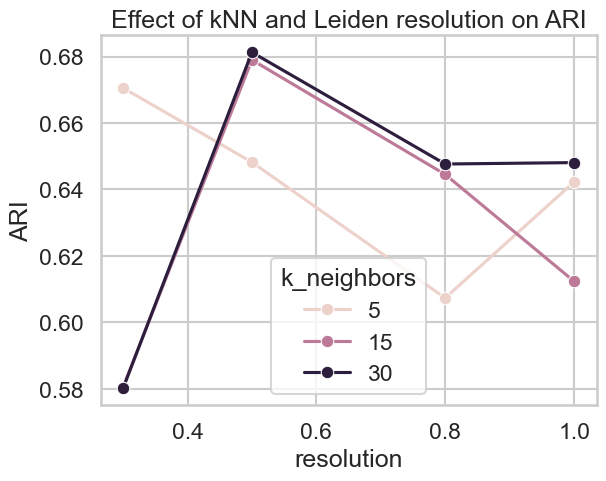

In [ ]:
sns.lineplot(
    data=ari_df,
    x="resolution",
    y="ARI",
    hue="k_neighbors",
    marker="o"
)

plt.title("Effect of kNN and Leiden resolution on ARI")
plt.show()

### That's all from this part! Thank you!

In [ ]:
#ok until here